In [14]:
import os
import zipfile
import urllib.request

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [15]:
df_mat = pd.read_csv('./datasets/student+performance/student/student-mat.csv', sep=";")
df_por = pd.read_csv('./datasets/student+performance/student/student-por.csv', sep=";")

print("student-mat.csv loaded:", df_mat is not None)
print("student-por.csv loaded:", df_por is not None)

df = df_mat if df_mat is not None else df_por

df.head()

student-mat.csv loaded: True
student-por.csv loaded: True


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [16]:
print("Missing values per column:")
print(df.isnull().sum())

# Drop rows with missing values if any
df = df.dropna().reset_index(drop=True)

# Select target variable
target = "G3"
X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64
X shape: (395, 32)
y shape: (395,)


In [17]:

from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train_raw.shape, y_train.shape)
print("Test shape:", X_test_raw.shape, y_test.shape)

Train shape: (316, 32) (316,)
Test shape: (79, 32) (79,)


In [18]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = X_train_raw.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X_train_raw.select_dtypes(exclude=["object"]).columns.tolist()

# One-hot encode categorical variables
X_train_cat = pd.get_dummies(X_train_raw[categorical_features], drop_first=True)
X_test_cat = pd.get_dummies(X_test_raw[categorical_features], drop_first=True)

# Align test set to training set columns
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

# Scale numerical features
scaler = StandardScaler()
X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train_raw[numerical_features]),
    columns=numerical_features,
    index=X_train_raw.index
)
X_test_num = pd.DataFrame(
    scaler.transform(X_test_raw[numerical_features]),
    columns=numerical_features,
    index=X_test_raw.index
)

# Combine processed features
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

print("Processed training shape:", X_train.shape)
print("Processed testing shape:", X_test.shape)

Processed training shape: (316, 41)
Processed testing shape: (79, 41)


In [19]:
X_train_np = X_train.values.astype(float)
X_test_np = X_test.values.astype(float)
y_train_np = y_train.values.astype(float).reshape(-1, 1)
y_test_np = y_test.values.astype(float).reshape(-1, 1)

# Add bias term
X_train_bias = np.c_[np.ones((X_train_np.shape[0], 1)), X_train_np]
X_test_bias = np.c_[np.ones((X_test_np.shape[0], 1)), X_test_np]

print("Bias-added training shape:", X_train_bias.shape)
print("Bias-added testing shape:", X_test_bias.shape)

Bias-added training shape: (316, 42)
Bias-added testing shape: (79, 42)


In [20]:
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X @ theta
    error = predictions - y
    return (1 / (2 * m)) * np.sum(error ** 2)

def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []

    for _ in range(iterations):
        predictions = X @ theta
        error = predictions - y
        gradients = (1 / m) * (X.T @ error)
        theta = theta - alpha * gradients
        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

iterations = 1000
learning_rates = [0.001, 0.01, 0.1]

results = {}
for lr in learning_rates:
    theta_init = np.zeros((X_train_bias.shape[1], 1))
    theta, cost_history = gradient_descent(X_train_bias, y_train_np, theta_init, lr, iterations)
    results[lr] = {
        "theta": theta,
        "cost_history": cost_history
    }
    print(f"Learning rate {lr}: final cost = {cost_history[-1]:.4f}")

Learning rate 0.001: final cost = 2.9983
Learning rate 0.01: final cost = 1.8945
Learning rate 0.1: final cost = 1.4646


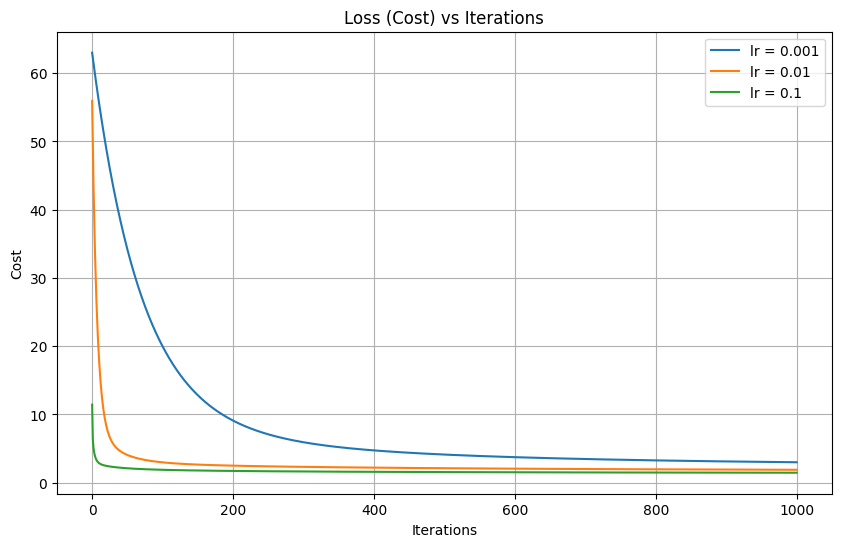

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

for lr in learning_rates:
    plt.plot(results[lr]["cost_history"], label=f"lr = {lr}")

plt.title("Loss (Cost) vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_lr = min(learning_rates, key=lambda lr: results[lr]["cost_history"][-1])
best_theta = results[best_lr]["theta"]

y_pred = X_test_bias @ best_theta

mse = mean_squared_error(y_test_np, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_np, y_pred)
r2 = r2_score(y_test_np, y_pred)

print("Best learning rate:", best_lr)
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")

Best learning rate: 0.1
MSE : 5.6690
RMSE: 2.3810
MAE : 1.6856
R2  : 0.7235


In [23]:
print("Interpretation:")
print(f"- Learning rate {best_lr} gave the lowest final cost among the tested values.")
print("- Smaller learning rates usually converge more slowly but more steadily.")
print("- Larger learning rates may converge faster, but can overshoot or become unstable.")
print("- Lower MAE/RMSE and higher R2 indicate better prediction performance.")
print("- If the cost curve decreases smoothly, gradient descent is converging properly.")

Interpretation:
- Learning rate 0.1 gave the lowest final cost among the tested values.
- Smaller learning rates usually converge more slowly but more steadily.
- Larger learning rates may converge faster, but can overshoot or become unstable.
- Lower MAE/RMSE and higher R2 indicate better prediction performance.
- If the cost curve decreases smoothly, gradient descent is converging properly.
